# 🦠 COVID-19 Data Analysis
> Analyzing global COVID-19 trends using Python, Pandas, and Seaborn.

**Topics covered:** Daily trends · Country comparisons · Death vs Recovery analysis · Data cleaning

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 2. Load & Explore Dataset

In [3]:
# Load dataset
df = pd.read_csv('covid.csv')

# Normalize column names for the notebook
df.rename(columns={
	'Province/State': 'province_state',
	'Country/Region': 'country',
	'Lat': 'lat',
	'Long': 'long',
	'Date': 'date',
	'Confirmed': 'cases',
	'Deaths': 'deaths',
	'Recovered': 'recoveries',
	'Active': 'active',
	'WHO Region': 'who_region'
}, inplace=True)

df['date'] = pd.to_datetime(df['date'])

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDate range:', df['date'].min(), '→', df['date'].max())
df.head()

Shape: (49068, 10)

Columns: ['province_state', 'country', 'lat', 'long', 'date', 'cases', 'deaths', 'recoveries', 'active', 'who_region']

Date range: 2020-01-22 00:00:00 → 2020-07-27 00:00:00


,province_state,country,lat,long,date,cases,deaths,recoveries,active,who_region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is clean ✅')

Missing values per column:
province_state    34404
dtype: int64


## 3. Data Cleaning

In [5]:
# Fill missing numeric values with 0 (no recorded = no cases)
numeric_cols = ['cases', 'deaths', 'recoveries']
df[numeric_cols] = df[numeric_cols].fillna(0)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Sort chronologically
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Derived columns
df['active_cases'] = df['cases'] - df['deaths'] - df['recoveries']
df['fatality_rate'] = (df['deaths'] / df['cases'].replace(0, pd.NA) * 100).round(2)

print('Data cleaned ✅')
df[['date','cases','deaths','recoveries','active_cases','fatality_rate']].tail()

Data cleaned ✅


,date,cases,deaths,recoveries,active_cases,fatality_rate
49063,2020-07-27,13547,613,12417,517,4.524987
49064,2020-07-27,5059,58,4977,24,1.146472
49065,2020-07-27,64156,1083,30204,32869,1.688073
49066,2020-07-27,92482,4652,34838,52992,5.030168
49067,2020-07-27,505,12,128,365,2.376238


## 4. Daily COVID-19 Cases Trend

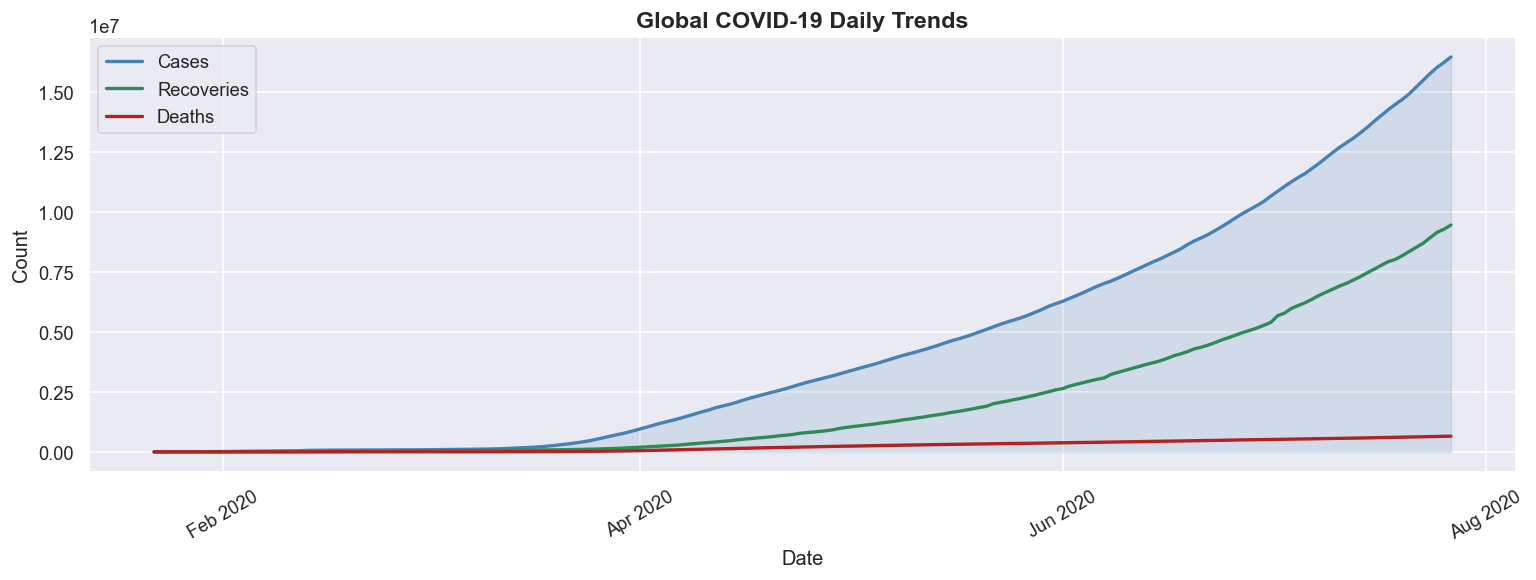

In [6]:
daily = df.groupby('date')[['cases', 'deaths', 'recoveries']].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(daily['date'], daily['cases'], alpha=0.15, color='steelblue')
ax.plot(daily['date'], daily['cases'], color='steelblue', linewidth=2, label='Cases')
ax.plot(daily['date'], daily['recoveries'], color='seagreen', linewidth=2, label='Recoveries')
ax.plot(daily['date'], daily['deaths'], color='firebrick', linewidth=2, label='Deaths')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)

ax.set_title('Global COVID-19 Daily Trends', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('trend_chart.png', bbox_inches='tight')
plt.show()

## 5. Top 10 Countries by Total Cases

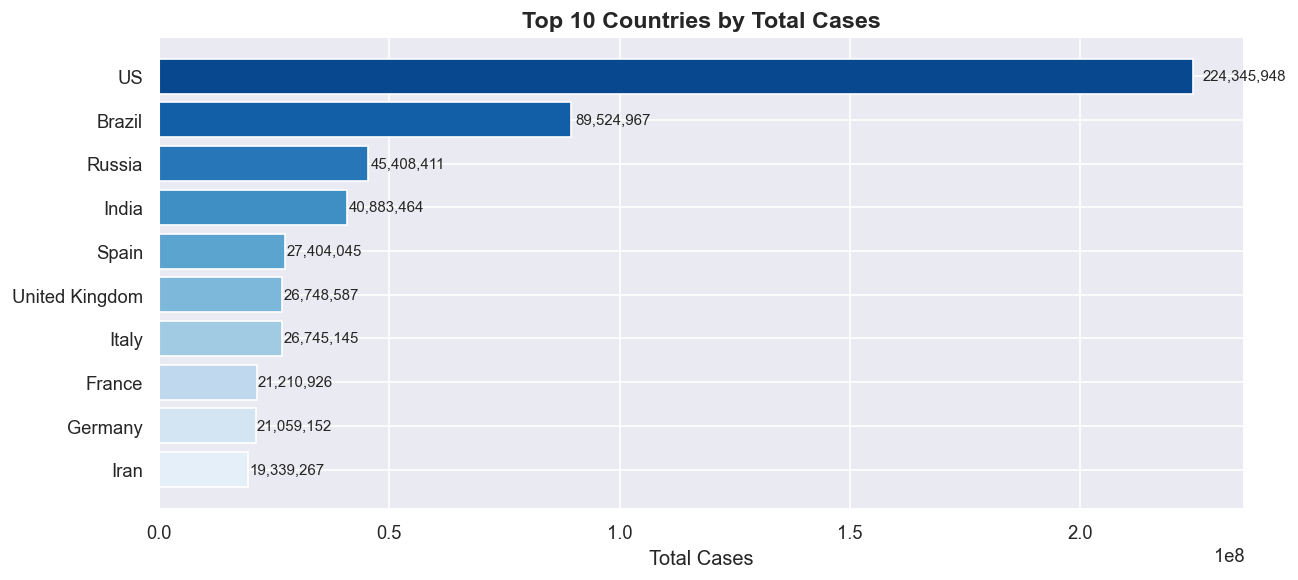

In [7]:
top10 = (
    df.groupby('country')['cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top10['country'], top10['cases'], color=sns.color_palette('Blues_r', 10))

# Annotate bars
for bar, val in zip(bars, top10['cases']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Countries by Total Cases', fontweight='bold')
ax.set_xlabel('Total Cases')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top10_countries.png', bbox_inches='tight')
plt.show()

## 6. Deaths vs Recoveries — Top 10 Countries

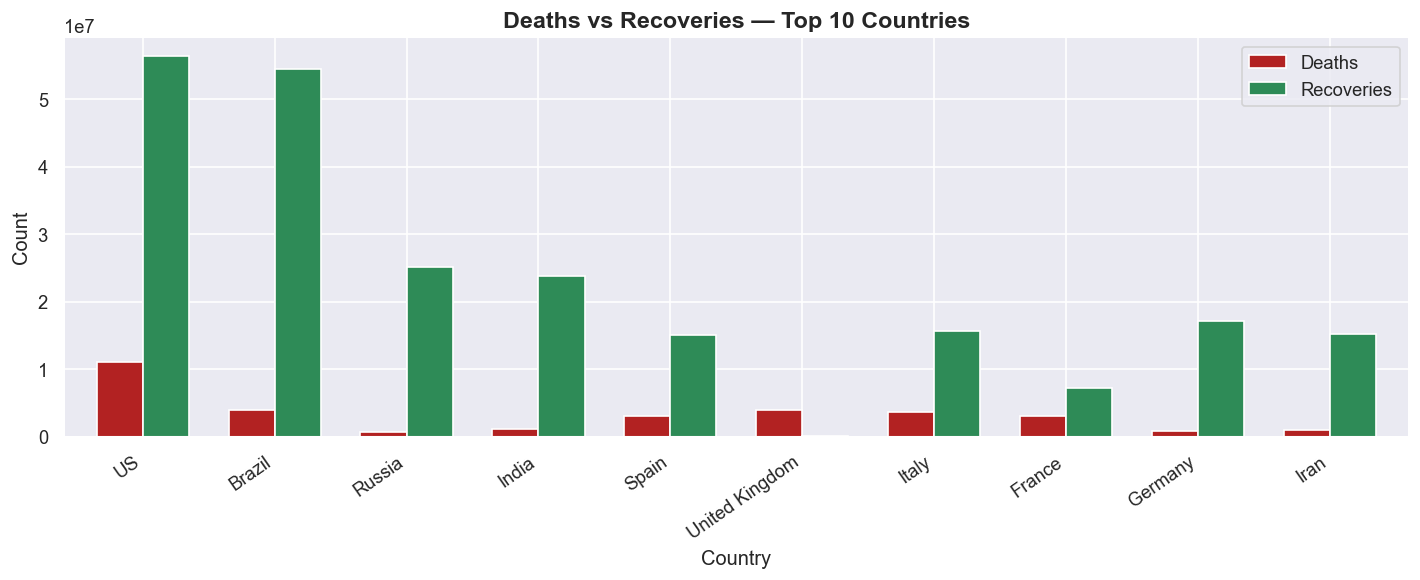

In [8]:
top10_names = top10['country'].tolist()
df_group = (
    df[df['country'].isin(top10_names)]
    .groupby('country')[['deaths', 'recoveries']]
    .sum()
    .loc[top10_names]  # preserve ranking order
)

df_group.plot(kind='bar', figsize=(12, 5),
              color=['firebrick', 'seagreen'],
              edgecolor='white', width=0.7)

plt.title('Deaths vs Recoveries — Top 10 Countries', fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.legend(['Deaths', 'Recoveries'])
plt.tight_layout()
plt.savefig('deaths_vs_recoveries.png', bbox_inches='tight')
plt.show()

## 7. Case Fatality Rate — Top 10 Countries

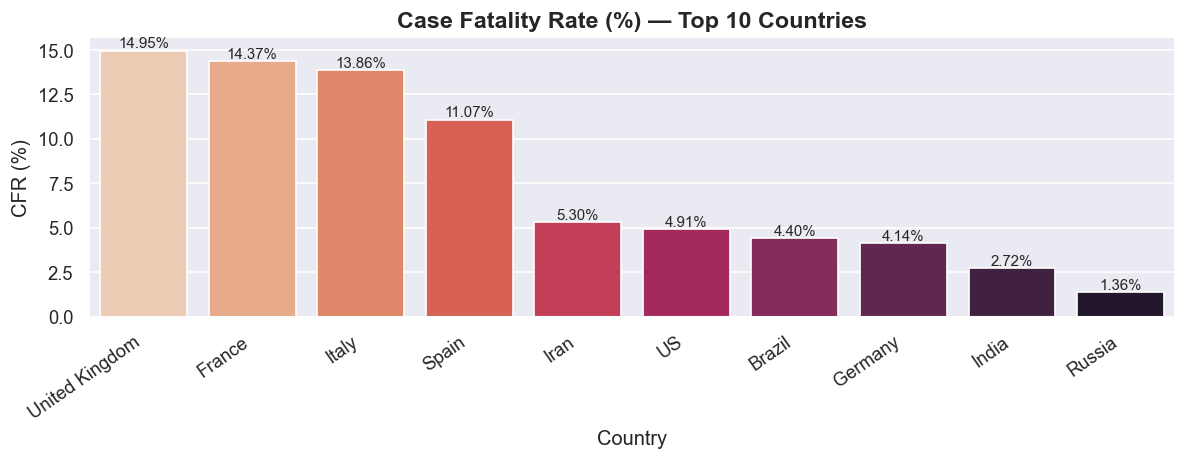

In [9]:
cfr = (
    df[df['country'].isin(top10_names)]
    .groupby('country')[['cases','deaths']]
    .sum()
)
cfr['cfr_%'] = (cfr['deaths'] / cfr['cases'] * 100).round(2)
cfr = cfr.sort_values('cfr_%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=cfr.index, y=cfr['cfr_%'], palette='rocket_r', ax=ax)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

ax.set_title('Case Fatality Rate (%) — Top 10 Countries', fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('CFR (%)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('cfr_chart.png', bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [10]:
totals = df[['cases','deaths','recoveries']].sum()
global_cfr = round(totals['deaths'] / totals['cases'] * 100, 2)
global_rr = round(totals['recoveries'] / totals['cases'] * 100, 2)

print('=' * 40)
print('       GLOBAL SUMMARY')
print('=' * 40)
print(f"Total Cases      : {totals['cases']:>15,.0f}")
print(f"Total Deaths     : {totals['deaths']:>15,.0f}")
print(f"Total Recoveries : {totals['recoveries']:>15,.0f}")
print(f"Case Fatality    : {global_cfr:>14}%")
print(f"Recovery Rate    : {global_rr:>14}%")
print('=' * 40)

       GLOBAL SUMMARY
Total Cases      :     828,508,482
Total Deaths     :      43,384,903
Total Recoveries :     388,408,229
Case Fatality    :           5.24%
Recovery Rate    :          46.88%
